# HARQ Playground

This notebook mirrors the `hello_estimate.ipynb` pipeline while showcasing the regional `Square` layout and `RegionalArchitecture`, where memory and communication use SSM while compute and factories use SSOQ.


In [1]:
from collections import Counter
import cirq
import numpy as np
import warnings
import sys

sys.path.append("../")
import resource_estimation as res

warnings.filterwarnings("ignore", category=FutureWarning)

## Input Circuit

The circuit is built from standard one- and two-qubit gates so it can be compiled into the Clifford + Rz and Clifford + T pipeline.

In [2]:
num_qubits = 10
depth = 2
rng = np.random.default_rng(7)

qubits = cirq.LineQubit.range(num_qubits)
circuit = cirq.Circuit()
for layer in range(depth):
    circuit.append(cirq.H.on_each(*qubits))
    circuit.append(cirq.rz(float(rng.uniform(-np.pi, np.pi))).on(q) for q in qubits)
    start = layer % 2
    circuit.append(cirq.CNOT(qubits[i], qubits[i + 1]) for i in range(start, num_qubits - 1, 2))

circuit

0: ───H───Rz(0.25π)─────@───H───Rz(-0.394π)───────
                        │
1: ───H───Rz(0.794π)────X───H───Rz(-0.443π)───@───
                                              │
2: ───H───Rz(0.551π)────@───H───Rz(-0.49π)────X───
                        │
3: ───H───Rz(-0.55π)────X───H───Rz(-0.11π)────@───
                                              │
4: ───H───Rz(-0.4π)─────@───H───Rz(0.009π)────X───
                        │
5: ───H───Rz(0.747π)────X───H───Rz(0.107π)────@───
                                              │
6: ───H───Rz(-0.989π)───@───H───Rz(0.991π)────X───
                        │
7: ───H───Rz(0.642π)────X───H───Rz(0.585π)────@───
                                              │
8: ───H───Rz(0.594π)────@───H───Rz(0.244π)────X───
                        │
9: ───H───Rz(-0.064π)───X───H───Rz(0.978π)────────

## Compile to Clifford + T

In [3]:
cliff_rz_circuit = res.cliff_rz.compile_cliff_rz(circuit)
grouped_ops = Counter(
    str(op.gate) if op.gate not in cirq.GateFamily(cirq.Rz) else "Rz"
    for op in cliff_rz_circuit.all_operations()
)
eps = 1 - 0.99 ** (1 / grouped_ops["Rz"])
synthesized_circuit = res.clifford_t.compile_cirq_to_clifford_t(
    cliff_rz_circuit,
    eps=eps,
    verbose=False,
)
print(f"Clifford + Rz moments: {len(cliff_rz_circuit)}")
print(f"Clifford + T moments: {len(synthesized_circuit)}")
print(grouped_ops)

Clifford + Rz moments: 8
Clifford + T moments: 402
Counter({'H': 20, 'Rz': 20, 'CNOT': 9})


## Square Regional Layout

Logical qubits start in the SSM memory region on the left. Operations are staged through a two-column SSM communication bus into the SSOQ compute region, while factories live in the SSOQ lower-right region. Cross-modality boundaries are represented by `ModalityTransfer` primitives.


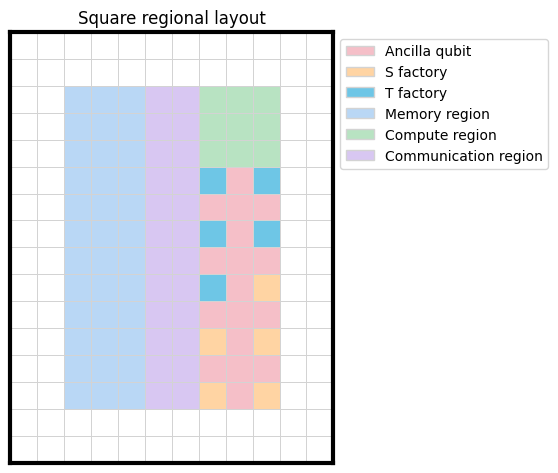

In [4]:
layout = res.layout.Square(
    input_circuit=synthesized_circuit,
    num_t_factories=5,
    num_s_factories=5,
    compute_capacity=4,
)
layout.visualize_layout(title="Square regional layout")


## Region-Local FT Compile and Estimate


In [5]:
arch = res.architecture.RegionalArchitecture.square_default(
    d=11,
    idling=False,
    post_op_correction=True,
    syndrome_rounds=1,
    cultivation_repetition=5,
    communication_move_factor=3.0,
    transfer_penalty=1.0,
)
primitive_circuit = res.compile_ftqc.ft_compile(layout=layout, arc=arch, verbose=False)
estimator = res.estimate.ResourceEstimator(arc=arch, layout=layout)
gate_cost = estimator.parallel_circuit_cost(primitive_circuit, pretty=True)
circuit_time = estimator.parallel_circuit_time(primitive_circuit)
physical_qubits = estimator.physical_qubits(primitive_circuit)


In [6]:
print(arch)
print("*" * 33)
print("Critical-path physical costs")
for op, count in sorted(gate_cost.items(), key=lambda x: x[1], reverse=True):
    print(f"{op}{' ' * max(1, 25 - len(op))}{count:.2e}")
print("*" * 33)
print("Metrics")
print(f"Time (μs){' ' * 16}{circuit_time:.2e}")
print(f"Qubits{' ' * 19}{physical_qubits:.2e}")
print("*" * 33)


RegionalArchitecture(memory=SingleSpeciesMovement, communication=SingleSpeciesMovement, compute=Superconductor, factory=Superconductor)
*********************************
Critical-path physical costs
CZ                       1.92e+05
PhasedXZGate             9.68e+04
MeasurementGate          4.96e+04
ResetChannel             4.96e+04
QubitPermutationGate     2.78e+04
ModalityTransfer         3.82e+03
*********************************
Metrics
Time (μs)                4.53e+06
Qubits                   2.31e+04
*********************************


In [7]:
serial_counts = estimator.serial_circuit_cost(primitive_circuit, pretty=False)
serial_time = estimator.serial_circuit_time(primitive_circuit)
parallel_time = estimator.parallel_circuit_time(primitive_circuit)
primitive_counts = Counter(type(op.gate).__name__ for op in primitive_circuit.all_operations())


In [8]:
print(f"Parallel critical-path time (μs): {parallel_time:.6e}")
print(f"Serial total-operation time (μs): {serial_time:.6e}")
print(f"CommunicationMove primitives: {primitive_counts.get('CommunicationMove', 0)}")
print(f"ModalityTransfer primitives: {primitive_counts.get('ModalityTransfer', 0)}")
print(f"Merge primitives from SSOQ compute/factory routing: {primitive_counts.get('Merge', 0)}")
print(f"Split primitives from SSOQ compute/factory routing: {primitive_counts.get('Split', 0)}")


Parallel critical-path time (μs): 4.525513e+06
Serial total-operation time (μs): 4.823266e+06
CommunicationMove primitives: 7648
ModalityTransfer primitives: 3824
Merge primitives from SSOQ compute/factory routing: 3720
Split primitives from SSOQ compute/factory routing: 3720
